In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Loading Data

In [2]:
data=pd.read_csv(r"C:\Users\rudra\Downloads\loan_prediction.csv")
data.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


## Exploratory Data Analysis

In [3]:
data.shape

(614, 13)

In [4]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum().sum()

np.int64(149)

In [6]:
data.drop(columns='Loan_ID',inplace=True)
data['Loan_Status']=data['Loan_Status'].replace({'Y':1,
                                                 'N':0})
data.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0


## Dependents

In [7]:
data['Dependents'].fillna(data['Dependents'].mode()[0],inplace=True)
data['Dependents']=data['Dependents'].replace('3+','4')
data['Dependents']=data['Dependents'].astype(int)
data['Dependents'].unique()

array([0, 1, 2, 4])

In [8]:
data['Loan_Amount_Term']=data['Loan_Amount_Term']/12
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean(),inplace=True)
data['Loan_Amount_Term']=data['Loan_Amount_Term'].astype(int)
data['Credit_History'].fillna(data['Credit_History'].mode()[0],inplace=True)
data['Credit_History']=data['Credit_History'].astype(int)
data.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,30,1,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30,1,Rural,0


In [9]:
data['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

## Loan Status

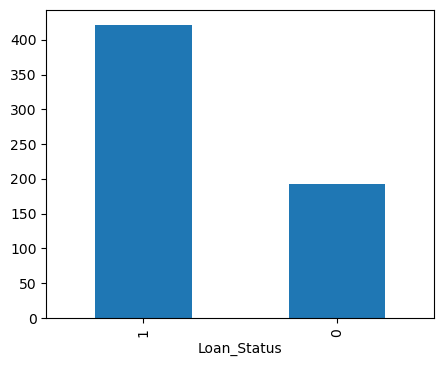

In [10]:
plt.figure(figsize=(5,4))
data['Loan_Status'].value_counts().plot(kind='bar')
plt.show()

## ApplicantIncome	CoapplicantIncome	LoanAmount	

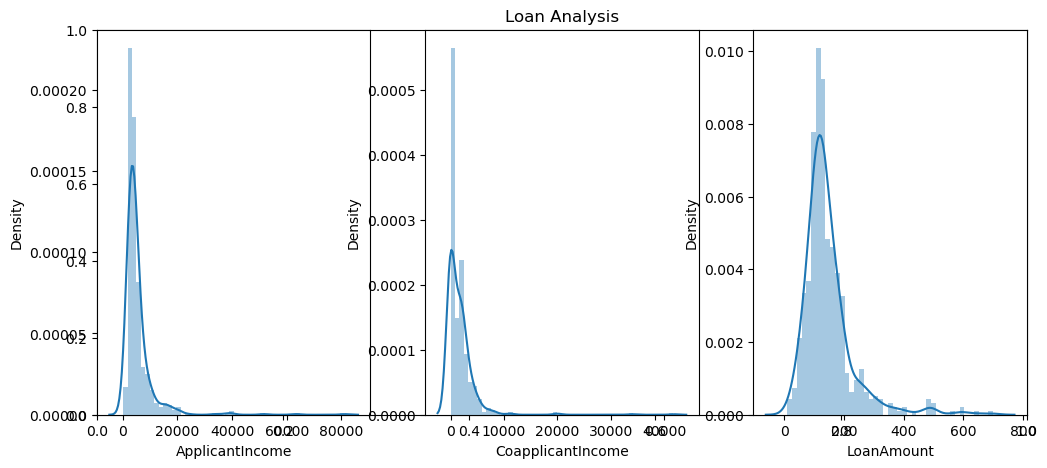

In [11]:
loan=['ApplicantIncome','CoapplicantIncome','LoanAmount']
i=1
plt.figure(figsize=(12,5))
plt.title("Loan Analysis")
for j in loan:
    plt.subplot(1,3,i)
    sns.distplot(data[j],kde=True)
    i=i+1

## Data Preprocessing 

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
onehot=['Gender']
ordinal=['Married','Education','Self_Employed','Property_Area']
scale=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
one_pipe=Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('one',OneHotEncoder(sparse_output=False,dtype=np.int32))
])
ord_pipe=Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('ord',OrdinalEncoder(categories=[['No','Yes'],['Not Graduate','Graduate'],['No','Yes'],['Rural','Semiurban','Urban']],
                          dtype=np.int32))
])
scale_pipe=Pipeline([
    ('impute',SimpleImputer(strategy='median')),
    ('scale',MinMaxScaler())
])

## Column Transformer

In [13]:
ct=ColumnTransformer([
    ('one',one_pipe,onehot),
    ('ord',ord_pipe,ordinal),
    ('scale',scale_pipe,scale)],remainder='passthrough')
ct

ColumnTransformer(remainder='passthrough',
                  transformers=[('one',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one',
                                                  OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                sparse_output=False))]),
                                 ['Gender']),
                                ('ord',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['Not '
                                                                              'Graduate',
                                                                              'Graduate'],
                                                                             ['No',
                                                                              'Yes'],
                                                                             ['Rural',
                                                                              'Semiurban',
                                                                              'Urban']],
                                                                 dtype=<class 'numpy.int32'>))]),
                                 ['Married', 'Education', 'Self_Employed',
                                  'Property_Area']),
                                ('scale',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount', 'Loan_Amount_Term'])])

## Train Test Split

In [14]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

## SVM PIPELINE

In [15]:
from sklearn.svm import SVC
svm_pipe=Pipeline([
    ('ct',ct),
    ('svc',SVC(class_weight='balanced',kernel='linear',C=0.1,probability=True))
])
svm_pipe.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one',
                                                                   OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                 sparse_output=False))]),
                                                  ['Gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['No',...
                                                                                               'Semiurban',
                                                                                               'Urban']],
                                                                                  dtype=<class 'numpy.int32'>))]),
                                                  ['Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('scale',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term'])])),
                ('svc',
                 SVC(C=0.1, class_weight='balanced', kernel='linear',
                     probability=True))])

## Traing Testing Score

In [16]:
print("Training Accuracy :",svm_pipe.score(x_train,y_train)*100)
print("Testing Accuracy :",svm_pipe.score(x_test,y_test)*100)
y_prd=svm_pipe.predict(x_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_prd)*100)

Training Accuracy : 81.52173913043478
Testing Accuracy : 75.80645161290323
75.80645161290323


## Classfication Metrics

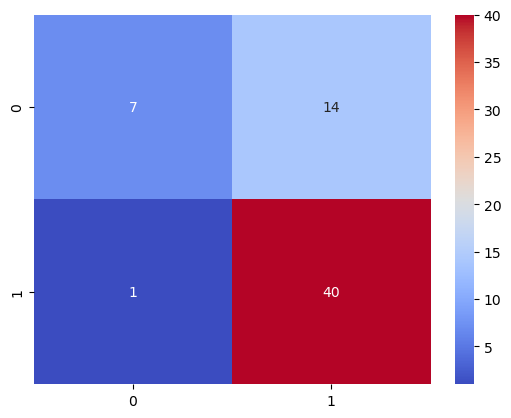

Precission Score : 74.07407407407408
Recall Score : 97.5609756097561
F1 Score : 84.21052631578947


In [17]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,svm_pipe.predict(x_test))
sns.heatmap(cm,annot=True,cmap='coolwarm')
plt.show()
print("Precission Score :",precision_score(y_test,svm_pipe.predict(x_test))*100)
print("Recall Score :",recall_score(y_test,svm_pipe.predict(x_test))*100)
print("F1 Score :",f1_score(y_test,svm_pipe.predict(x_test))*100)

## Logistic Regression Pipeline

In [18]:
from sklearn.linear_model import LogisticRegression
lr_pipe=Pipeline([
    ('ct',ct),
    ('lr',LogisticRegression(class_weight={0:5,
                                           1:2}))
])
lr_pipe.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one',
                                                                   OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                 sparse_output=False))]),
                                                  ['Gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['No',...
                                                                                              ['No',
                                                                                               'Yes'],
                                                                                              ['Rural',
                                                                                               'Semiurban',
                                                                                               'Urban']],
                                                                                  dtype=<class 'numpy.int32'>))]),
                                                  ['Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('scale',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term'])])),
                ('lr', LogisticRegression(class_weight={0: 5, 1: 2}))])

## Traing Testing Score

In [19]:
print("Training Score :",lr_pipe.score(x_train,y_train)*100)
print("Testing Score :",lr_pipe.score(x_test,y_test)*100)

Training Score : 77.53623188405797
Testing Score : 75.80645161290323


## Classfication Metrics

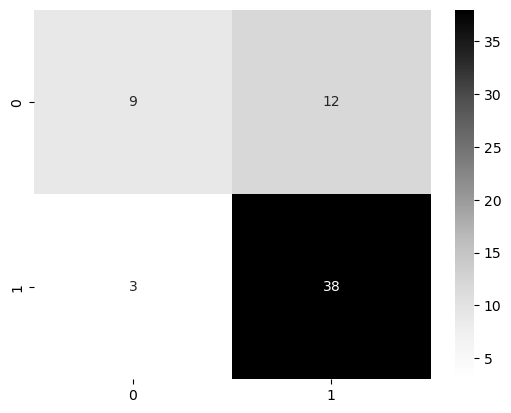

Precission Score : 76.0
Recall Score : 92.6829268292683
F1 Score : 83.51648351648352


In [20]:
cm=confusion_matrix(y_test,lr_pipe.predict(x_test))
sns.heatmap(cm,annot=True,cmap='Greys')
plt.show()
print("Precission Score :",precision_score(y_test,lr_pipe.predict(x_test))*100)
print("Recall Score :",recall_score(y_test,lr_pipe.predict(x_test))*100)
print("F1 Score :",f1_score(y_test,lr_pipe.predict(x_test))*100)

## Naive Bayes Pipeline

In [21]:
from sklearn.naive_bayes import GaussianNB
gnb_pipe=Pipeline([
    ('ct',ct),
    ('gnb',GaussianNB())
])
gnb_pipe.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one',
                                                                   OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                 sparse_output=False))]),
                                                  ['Gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['No',...
                                                                                              ['Not '
                                                                                               'Graduate',
                                                                                               'Graduate'],
                                                                                              ['No',
                                                                                               'Yes'],
                                                                                              ['Rural',
                                                                                               'Semiurban',
                                                                                               'Urban']],
                                                                                  dtype=<class 'numpy.int32'>))]),
                                                  ['Married', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('scale',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term'])])),
                ('gnb', GaussianNB())])

## Traing Testing Score

In [22]:
print("Training Score :",gnb_pipe.score(x_train,y_train)*100)
print("Testing Score :",gnb_pipe.score(x_test,y_test)*100)

Training Score : 80.43478260869566
Testing Score : 75.80645161290323


## Classfication Metrics

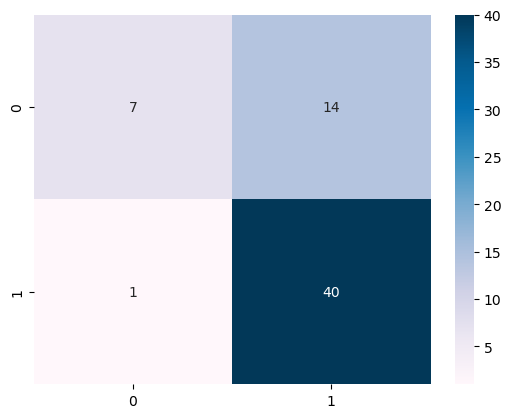

Precission Score : 74.07407407407408
Recall Score : 97.5609756097561
F1 Score : 84.21052631578947


In [23]:
cm=confusion_matrix(y_test,gnb_pipe.predict(x_test))
sns.heatmap(cm,annot=True,cmap='PuBu')
plt.show()
print("Precission Score :",precision_score(y_test,gnb_pipe.predict(x_test))*100)
print("Recall Score :",recall_score(y_test,gnb_pipe.predict(x_test))*100)
print("F1 Score :",f1_score(y_test,gnb_pipe.predict(x_test))*100)

## Random Forest Pipeline

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_pipe=Pipeline([
    ('ct',ct),
    ('rf',RandomForestClassifier(n_estimators=200,max_samples=0.5,max_depth=6,class_weight="balanced",min_samples_split=25,
                                 oob_score=True,random_state=42))
])
rf_pipe.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one',
                                                                   OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                 sparse_output=False))]),
                                                  ['Gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['No',...
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('scale',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        max_samples=0.5, min_samples_split=25,
                                        n_estimators=200, oob_score=True,
                                        random_state=42))])

## Traing Testing Score

In [25]:
print("Training Score :",rf_pipe.score(x_train,y_train)*100)
print("Testing Score :",rf_pipe.score(x_test,y_test)*100)

Training Score : 84.78260869565217
Testing Score : 74.19354838709677


## Classfication Metrics

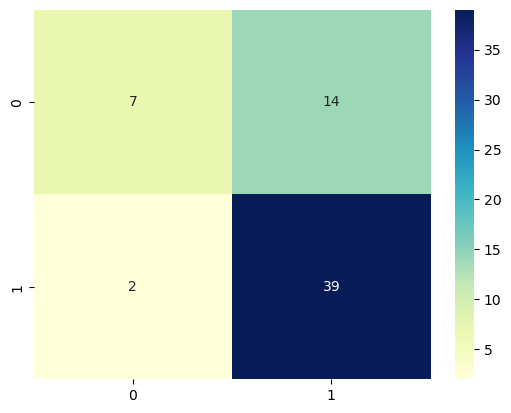

Precission Score : 73.58490566037736
Recall Score : 95.1219512195122
F1 Score : 82.97872340425532


In [26]:
cm=confusion_matrix(y_test,rf_pipe.predict(x_test))
sns.heatmap(cm,annot=True,cmap='YlGnBu')
plt.show()
print("Precission Score :",precision_score(y_test,rf_pipe.predict(x_test))*100)
print("Recall Score :",recall_score(y_test,rf_pipe.predict(x_test))*100)
print("F1 Score :",f1_score(y_test,rf_pipe.predict(x_test))*100)

## Voting Classfier Pipeline

In [27]:
from sklearn.ensemble import VotingClassifier
vcf_pipe=VotingClassifier(
    estimators=[
        ('lr',lr_pipe),
        ('svc',svm_pipe),
        ('gnb',gnb_pipe),
        ('rf',rf_pipe)
    ],voting='soft')
vcf_pipe.fit(x_train,y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('ct',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('one',
                                                                                Pipeline(steps=[('impute',
                                                                                                 SimpleImputer(strategy='most_frequent')),
                                                                                                ('one',
                                                                                                 OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                                               sparse_output=False))]),
                                                                                ['Gender']),
                                                                               ('ord',
                                                                                Pipeline(steps=[('impute',
                                                                                                 SimpleImputer(strategy='most_frequent')),
                                                                                                ('ord...
                                                                                 'Property_Area']),
                                                                               ('scale',
                                                                                Pipeline(steps=[('impute',
                                                                                                 SimpleImputer(strategy='median')),
                                                                                                ('scale',
                                                                                                 MinMaxScaler())]),
                                                                                ['ApplicantIncome',
                                                                                 'CoapplicantIncome',
                                                                                 'LoanAmount',
                                                                                 'Loan_Amount_Term'])])),
                                              ('rf',
                                               RandomForestClassifier(class_weight='balanced',
                                                                      max_depth=6,
                                                                      max_samples=0.5,
                                                                      min_samples_split=25,
                                                                      n_estimators=200,
                                                                      oob_score=True,
                                                                      random_state=42))]))],
                 voting='soft')

## Traing Testing Score

In [28]:
print("Training Score :",vcf_pipe.score(x_train,y_train)*100)
print("Testing Score :",vcf_pipe.score(x_test,y_test)*100)

Training Score : 81.70289855072464
Testing Score : 75.80645161290323


## Classfication Metrics

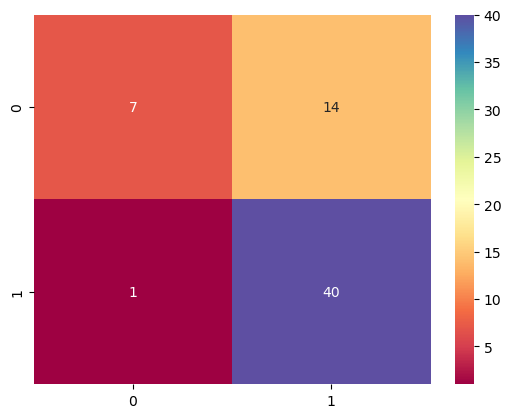

Precission Score : 74.07407407407408
Recall Score : 97.5609756097561
F1 Score : 84.21052631578947


In [29]:
cm=confusion_matrix(y_test,vcf_pipe.predict(x_test))
sns.heatmap(cm,annot=True,cmap='Spectral')
plt.show()
print("Precission Score :",precision_score(y_test,vcf_pipe.predict(x_test))*100)
print("Recall Score :",recall_score(y_test,vcf_pipe.predict(x_test))*100)
print("F1 Score :",f1_score(y_test,vcf_pipe.predict(x_test))*100)

## Bagging Classfier

In [30]:
from sklearn.ensemble import BaggingClassifier
bag_pipe=Pipeline([
    ('ct',ct),
    ('bagging',BaggingClassifier(estimator=SVC(class_weight="balanced",C=0.1,kernel='linear'),
                                 n_estimators=100,
                                 max_samples=0.25,
                                 bootstrap=False,
                                 random_state=42))
])
bag_pipe.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one',
                                                                   OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                 sparse_output=False))]),
                                                  ['Gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['No',...
                                                   'Self_Employed',
                                                   'Property_Area']),
                                                 ('scale',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term'])])),
                ('bagging',
                 BaggingClassifier(bootstrap=False,
                                   estimator=SVC(C=0.1, class_weight='balanced',
                                                 kernel='linear'),
                                   max_samples=0.25, n_estimators=100,
                                   random_state=42))])

## Traing Testing Score

In [31]:
print("Training Score :",bag_pipe.score(x_train,y_train)*100)
print("Testing Score :",bag_pipe.score(x_test,y_test)*100)

Training Score : 81.52173913043478
Testing Score : 75.80645161290323


## Classfication Metrics

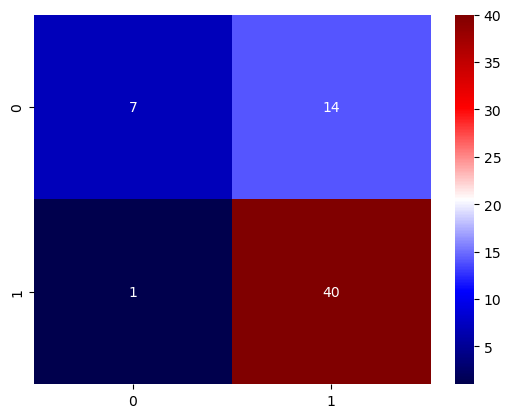

Precission Score : 74.07407407407408
Recall Score : 97.5609756097561
F1 Score : 84.21052631578947


In [32]:
cm=confusion_matrix(y_test,bag_pipe.predict(x_test))
sns.heatmap(cm,annot=True,cmap='seismic')
plt.show()
print("Precission Score :",precision_score(y_test,bag_pipe.predict(x_test))*100)
print("Recall Score :",recall_score(y_test,bag_pipe.predict(x_test))*100)
print("F1 Score :",f1_score(y_test,bag_pipe.predict(x_test))*100)

## Hyper Prameter Tuing with Bagging

In [33]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.model_selection import cross_val_score
params={
    'bagging__estimator':[SVC(class_weight="balanced",kernel='rbf'),
                          LogisticRegression(class_weight="balanced"),
                          GaussianNB(),
                          RandomForestClassifier(class_weight="balanced",n_estimators=200,max_samples=0.5)
                         ],
    'bagging__n_estimators':[100,150,200,250,300],
    'bagging__max_samples':[0.3,0.4,0.5,0.6,0.25],
    'bagging__bootstrap':[False,True]
}
params

{'bagging__estimator': [SVC(class_weight='balanced'),
  LogisticRegression(class_weight='balanced'),
  GaussianNB(),
  RandomForestClassifier(class_weight='balanced', max_samples=0.5,
                         n_estimators=200)],
 'bagging__n_estimators': [100, 150, 200, 250, 300],
 'bagging__max_samples': [0.3, 0.4, 0.5, 0.6, 0.25],
 'bagging__bootstrap': [False, True]}

In [34]:
##bag_hyper_pipe=GridSearchCV(estimator=bag_pipe,param_grid=params,cv=5,scoring="accuracy")
##bag_hyper_pipe.fit(x_train,y_train)

In [39]:
bag_hyper_pipe=RandomizedSearchCV(bag_pipe,params,n_iter=5,cv=2,scoring="accuracy")
bag_hyper_pipe.fit(x_train,y_train)

RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('ct',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('one',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('one',
                                                                                                OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                                                              sparse_output=False))]),
                                                                               ['Gender']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ord'...
                   param_distributions={'bagging__bootstrap': [False, True],
                                        'bagging__estimator': [SVC(class_weight='balanced'),
                                                               LogisticRegression(class_weight='balanced'),
                                                               GaussianNB(),
                                                               RandomForestClassifier(class_weight='balanced',
                                                                                      max_samples=0.5,
                                                                                      n_estimators=200)],
                                        'bagging__max_samples': [0.3, 0.4, 0.5,
                                                                 0.6, 0.25],
                                        'bagging__n_estimators': [100, 150, 200,
                                                                  250, 300]},
                   scoring='accuracy')

In [37]:
bag_hyper_pipe.best_score_

np.float64(0.7989130434782609)

In [38]:
bag_hyper_pipe.best_params_

{'bagging__n_estimators': 100,
 'bagging__max_samples': 0.4,
 'bagging__estimator': GaussianNB(),
 'bagging__bootstrap': False}

## Pickel File With Voting Classfier

In [41]:
import pickle
pickle.dump(vcf_pipe,open("Voting_Classifier.pkl","wb"))
vcf_pipe=pickle.load(open("Voting_Classifier.pkl","rb"))

In [43]:
vcf_pipe.predict(pd.DataFrame([['Male','Yes',1,'Graduate','No',4583,1508.0,128.0,30,1,'Rural']],columns=x_train.columns))

array([1])